In [1]:
# pandas: works with tables of data (like Excel in Python)
import pandas as pd

# numpy: mathematical operations on numbers
import numpy as np

# matplotlib & seaborn: create charts and graphs
import matplotlib.pyplot as plt
import seaborn as sns

# sqlalchemy: connects Python to SQL databases
from sqlalchemy import create_engine

# Tell matplotlib to show charts inside the notebook
%matplotlib inline

# Set a clean style for all charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


Creating CSV files for data analysis later

In [2]:
# We'll create 3 CSV files — one for each table we need
# This simulates receiving data files from different teams at work

# ── CSV 1: Customers ──────────────────────────────────────────
customers_data = """customer_id,full_name,email,city,signup_date
1,Alice Johnson,alice.johnson@gmail.com,New York,2022-03-15
2,Bob Smith,bsmith_1990@yahoo.com,Chicago,2022-07-22
3,Clara Nguyen,clara.nguyen@gmail.com,San Jose,2023-01-05
4,David Lee,david_lee@outlook.com,Houston,2021-11-30
5,Eva Martinez,eva.martinez@gmail.com,Phoenix,2023-06-18
6,Frank Brown,frankbrown@hotmail.com,Chicago,2022-09-09
7,Grace Kim,grace.kim@gmail.com,New York,2023-03-27
8,Henry Wilson,hwilson@work-email.com,Dallas,2021-05-14
9,Isla Thompson,isla.t@gmail.com,San Jose,2023-08-01
10,Jake Davis,jake_davis_99@yahoo.com,Phoenix,2022-12-20"""

# ── CSV 2: Products ───────────────────────────────────────────
products_data = """product_id,product_name,category,price
1,Wireless Headphones,Electronics,89.99
2,Running Shoes,Apparel,65.00
3,Coffee Maker,Kitchen,120.00
4,Python Book,Books,45.00
5,Yoga Mat,Fitness,35.00
6,Bluetooth Speaker,Electronics,110.00
7,Desk Lamp,Home Office,40.00
8,Protein Powder,Fitness,55.00
9,Novel - The Alchemist,Books,18.00
10,Air Fryer,Kitchen,145.00"""

# ── CSV 3: Orders ─────────────────────────────────────────────
orders_data = """order_id,customer_id,order_date,status
1,1,2024-01-10 09:15:00,delivered
2,2,2024-01-15 14:30:00,delivered
3,3,2024-02-02 11:00:00,returned
4,1,2024-02-14 16:45:00,delivered
5,4,2024-03-01 08:20:00,pending
6,5,2024-03-18 13:10:00,delivered
7,6,2024-04-05 10:55:00,delivered
8,7,2024-04-22 15:00:00,returned
9,3,2024-05-09 09:30:00,delivered
10,8,2024-05-25 17:45:00,delivered
11,9,2024-06-03 12:00:00,pending
12,10,2024-06-19 14:20:00,delivered
13,2,2024-07-07 11:35:00,delivered
14,5,2024-07-21 09:50:00,delivered
15,1,2024-08-08 16:15:00,returned"""

# Now write each one to a real CSV file on your computer
with open('customers.csv', 'w') as f:
    f.write(customers_data)

with open('products.csv', 'w') as f:
    f.write(products_data)

with open('orders.csv', 'w') as f:
    f.write(orders_data)

print('✅ CSV files created!')
print('📁 Check your project folder — you should see 3 new files')

✅ CSV files created!
📁 Check your project folder — you should see 3 new files


Reading CSV files to Dataframe

In [3]:
# Read each CSV file into a DataFrame
# pd.read_csv('filename') opens the file and loads it as a table

customers = pd.read_csv('customers.csv')
products  = pd.read_csv('products.csv')
orders    = pd.read_csv('orders.csv')


In [4]:

print('✅ Files loaded successfully! ')
print(f'   Customers: {len(customers)} rows')
print(f'   Products:  {len(products)} rows')
print(f'   Orders:    {len(orders)} rows')

✅ Files loaded successfully! 
   Customers: 10 rows
   Products:  10 rows
   Orders:    15 rows


In [5]:
# .head() shows the first 5 rows — like peeking at the top of a spreadsheet
# Remember this from our SQL project? It's the same idea as SELECT * LIMIT 5

print('── CUSTOMERS ──')
display(customers.head())

print('── PRODUCTS ──')
display(products.head())

print('── ORDERS ──')
display(orders.head())

── CUSTOMERS ──


,customer_id,full_name,email,city,signup_date
0,1,Alice Johnson,alice.johnson@gmail.com,New York,2022-03-15
1,2,Bob Smith,bsmith_1990@yahoo.com,Chicago,2022-07-22
2,3,Clara Nguyen,clara.nguyen@gmail.com,San Jose,2023-01-05
3,4,David Lee,david_lee@outlook.com,Houston,2021-11-30
4,5,Eva Martinez,eva.martinez@gmail.com,Phoenix,2023-06-18


── PRODUCTS ──


,product_id,product_name,category,price
0,1,Wireless Headphones,Electronics,89.99
1,2,Running Shoes,Apparel,65.00
2,3,Coffee Maker,Kitchen,120.00
3,4,Python Book,Books,45.00
4,5,Yoga Mat,Fitness,35.00


── ORDERS ──


,order_id,customer_id,order_date,status
0,1,1,2024-01-10 09:15:00,delivered
1,2,2,2024-01-15 14:30:00,delivered
2,3,3,2024-02-02 11:00:00,returned
3,4,1,2024-02-14 16:45:00,delivered
4,5,4,2024-03-01 08:20:00,pending


Loading CSVs to a SQL database.. SQLite is already preloaded with Python and doesn't reqquire a server like MySQL (hence the choice)

In [6]:
# create_engine() creates a connection to a database
# 'sqlite:///ecommerce.db' means:
#   sqlite  = database type (lightweight, no server needed)
#   ///     = stored locally as a file
#   ecommerce.db = the filename it creates on your computer

engine = create_engine('sqlite:///ecommerce.db')

# Write each DataFrame into the database as a table
# if_exists='replace' means overwrite if table already exists
customers.to_sql('customers', engine, if_exists='replace', index=False)
products.to_sql('products',   engine, if_exists='replace', index=False)
orders.to_sql('orders',       engine, if_exists='replace', index=False)

print('✅ Database created: ecommerce.db')
print('📁 Check your project folder — you should see ecommerce.db')

✅ Database created: ecommerce.db
📁 Check your project folder — you should see ecommerce.db


Query the Database Using SQL From Python

In [7]:
# pd.read_sql() takes two things:
# 1. Your SQL query (in quotes)
# 2. The database connection (engine)
# It returns the result as a DataFrame automatically!

# Query 1 — Basic select, just like we did in DB Fiddle
query = '''
    SELECT *
    FROM customers
'''

result = pd.read_sql(query, engine)
display(result)

,customer_id,full_name,email,city,signup_date
0,1,Alice Johnson,alice.johnson@gmail.com,New York,2022-03-15
1,2,Bob Smith,bsmith_1990@yahoo.com,Chicago,2022-07-22
2,3,Clara Nguyen,clara.nguyen@gmail.com,San Jose,2023-01-05
3,4,David Lee,david_lee@outlook.com,Houston,2021-11-30
4,5,Eva Martinez,eva.martinez@gmail.com,Phoenix,2023-06-18
5,6,Frank Brown,frankbrown@hotmail.com,Chicago,2022-09-09
6,7,Grace Kim,grace.kim@gmail.com,New York,2023-03-27
7,8,Henry Wilson,hwilson@work-email.com,Dallas,2021-05-14
8,9,Isla Thompson,isla.t@gmail.com,San Jose,2023-08-01
9,10,Jake Davis,jake_davis_99@yahoo.com,Phoenix,2022-12-20


In [8]:
# Query 2 — Now try a JOIN, exactly like our SQL project!
# See how the SQL inside is identical to what you wrote before?

query = '''
    SELECT c.full_name,
           c.city,
           o.order_date,
           o.status
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    ORDER BY o.order_date
'''

result = pd.read_sql(query, engine)
display(result)

,full_name,city,order_date,status
0,Alice Johnson,New York,2024-01-10 09:15:00,delivered
1,Bob Smith,Chicago,2024-01-15 14:30:00,delivered
2,Clara Nguyen,San Jose,2024-02-02 11:00:00,returned
3,Alice Johnson,New York,2024-02-14 16:45:00,delivered
4,David Lee,Houston,2024-03-01 08:20:00,pending
5,Eva Martinez,Phoenix,2024-03-18 13:10:00,delivered
6,Frank Brown,Chicago,2024-04-05 10:55:00,delivered
7,Grace Kim,New York,2024-04-22 15:00:00,returned
8,Clara Nguyen,San Jose,2024-05-09 09:30:00,delivered
9,Henry Wilson,Dallas,2024-05-25 17:45:00,delivered


In [9]:
# Building our main working DataFrame
# by joining all 3 tables together — just like our SQL capstone!

query = '''
    SELECT c.customer_id,
           c.full_name,
           c.city,
           c.email,
           c.signup_date,
           o.order_id,
           o.order_date,
           o.status
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    ORDER BY o.order_date
'''

df = pd.read_sql(query, engine)

# Now let's explore it
print('──── SHAPE ────')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

print('\n──── COLUMN NAMES & DATA TYPES ────')
print(df.dtypes)

print('\n──── MISSING VALUES ────')
print(df.isnull().sum())

──── SHAPE ────
Rows: 15
Columns: 8

──── COLUMN NAMES & DATA TYPES ────
customer_id    int64
full_name        str
city             str
email            str
signup_date      str
order_id       int64
order_date       str
status           str
dtype: object

──── MISSING VALUES ────
customer_id    0
full_name      0
city           0
email          0
signup_date    0
order_id       0
order_date     0
status         0
dtype: int64


Parsing date to a datetime type column and breaking it down

In [10]:
# pd.to_datetime() converts text into real Python datetime objects

df['order_date']  = pd.to_datetime(df['order_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Verify the fix worked
print('──── DATA TYPES AFTER FIX ────')
print(df[['order_date', 'signup_date']].dtypes)

──── DATA TYPES AFTER FIX ────
order_date     datetime64[us]
signup_date    datetime64[us]
dtype: object


In [11]:
# .dt gives us access to date parts — like SQL's date functions
# but using Python's dot notation instead

df['order_month']    = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.strftime('%B')  # Full month name
df['order_year']     = df['order_date'].dt.year
df['days_as_customer'] = (df['order_date'] - df['signup_date']).dt.days

print('──── NEW DATE COLUMNS ────')
display(df[['full_name', 'order_date', 'order_month_name', 'days_as_customer']].head(8))

──── NEW DATE COLUMNS ────


,full_name,order_date,order_month_name,days_as_customer
0,Alice Johnson,2024-01-10 09:15:00,January,666
1,Bob Smith,2024-01-15 14:30:00,January,542
2,Clara Nguyen,2024-02-02 11:00:00,February,393
3,Alice Johnson,2024-02-14 16:45:00,February,701
4,David Lee,2024-03-01 08:20:00,March,822
5,Eva Martinez,2024-03-18 13:10:00,March,274
6,Frank Brown,2024-04-05 10:55:00,April,574
7,Grace Kim,2024-04-22 15:00:00,April,392


Adding Email Type - Gmail or Not

In [12]:
# str.contains() is Python's version of REGEX pattern matching
# It checks if a string contains a pattern — returns True or False

df['email_type'] = df['email'].str.contains('gmail.com').map({
    True:  'Gmail',
    False: 'Other'
})

print('──── EMAIL TYPE COUNTS ────')
print(df['email_type'].value_counts())

──── EMAIL TYPE COUNTS ────
email_type
Gmail    9
Other    6
Name: count, dtype: int64


### Visualize Data

Bar 0: 10
Bar 1: 3
Bar 2: 2


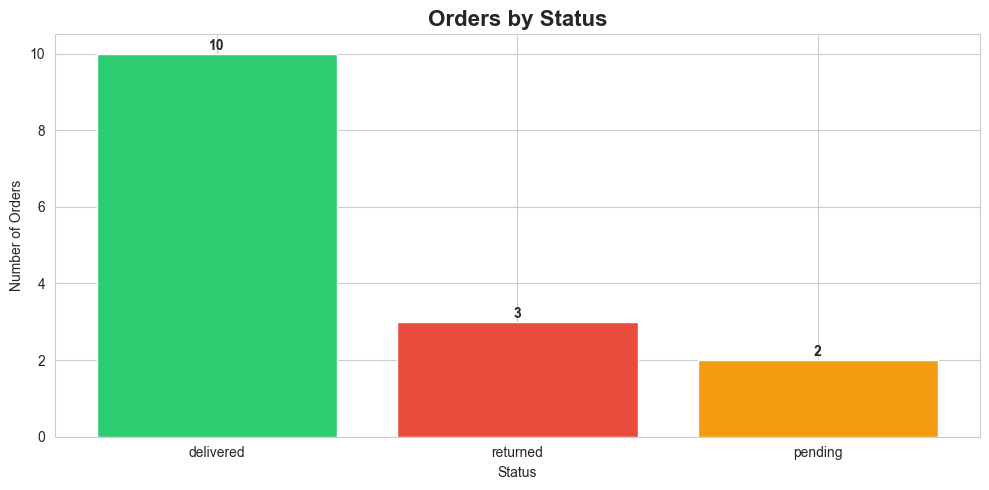

In [13]:
### Chart 1: Order by Status
## value_counts() counts each unique status
# .plot() turns it into a chart instantly

status_counts = df['status'].value_counts()

# Create the chart
fig, ax = plt.subplots()

ax.bar(status_counts.index,    # x axis: status labels
       status_counts.values,   # y axis: counts
       color=['#2ecc71', '#e74c3c', '#f39c12'])  # green, red, orange

# Add labels and title
ax.set_title('Orders by Status', fontsize=16, fontweight='bold')
ax.set_xlabel('Status')
ax.set_ylabel('Number of Orders')

# Add count numbers on top of each bar
for i, val in enumerate(status_counts.values):
    print(f'Bar {i}: {val}')  # Debug: check values and positions
    ax.text(i, val + 0.1, str(val), ha='center', fontweight='bold') # position text above bar

plt.tight_layout()
plt.show()

**Chart 2: Monthly Order Trend**

──── MONTHLY ORDER COUNTS ────


,month_num,month_name,order_count
0,1,January,2
1,2,February,2
2,3,March,2
3,4,April,2
4,5,May,2
5,6,June,2
6,7,July,2
7,8,August,1


Month: January, Orders: 2, Index: 0
Month: February, Orders: 2, Index: 1
Month: March, Orders: 2, Index: 2
Month: April, Orders: 2, Index: 3
Month: May, Orders: 2, Index: 4
Month: June, Orders: 2, Index: 5
Month: July, Orders: 2, Index: 6
Month: August, Orders: 1, Index: 7


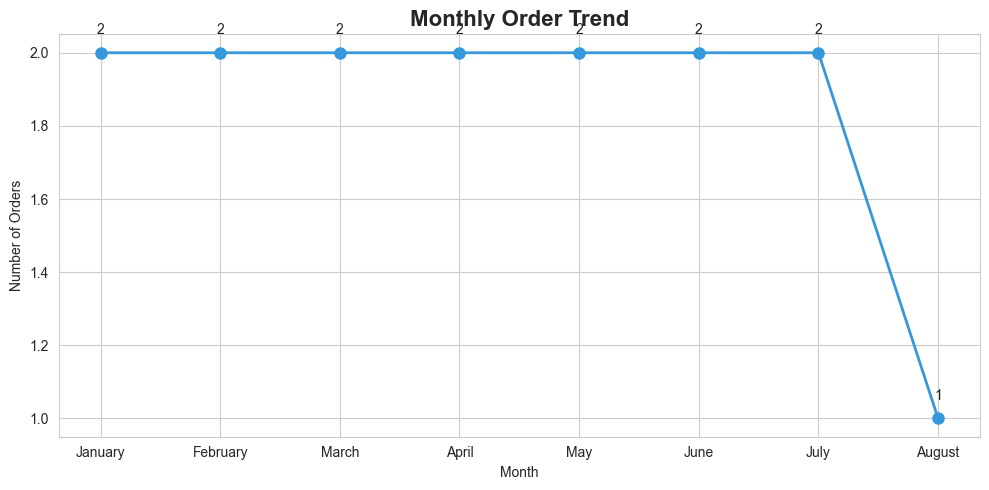

In [14]:

# Group by month and count orders — just like GROUP BY in SQL!
monthly = df.groupby(['order_month', 'order_month_name'])['order_id'].count().reset_index()
monthly.columns = ['month_num', 'month_name', 'order_count']
monthly = monthly.sort_values('month_num')  # sort chronologically
print('──── MONTHLY ORDER COUNTS ────')
display(monthly)
fig, ax = plt.subplots()

ax.plot(monthly['month_name'],   # x axis: month names
        monthly['order_count'],  # y axis: order counts
        marker='o',              # show a dot at each data point
        linewidth=2,
        color='#3498db',
        markersize=8)

ax.set_title('Monthly Order Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')

# Add value labels on each point
for _, row in monthly.iterrows(): #_ here represents the index, which we don't need
    print(f"Month: {row['month_name']}, Orders: {row['order_count']}, Index: {_}")
    ax.text(row['month_name'], row['order_count'] + 0.05,
            str(row['order_count']), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Chart 3: Orders by City and Status**

status    delivered  pending  returned
city                                  
Chicago           3        0         0
Dallas            1        0         0
Houston           0        1         0
New York          2        0         2
Phoenix           3        0         0
San Jose          1        1         1


status,delivered,pending,returned
city,,,
Chicago,3,0,0
Dallas,1,0,0
Houston,0,1,0
New York,2,0,2
Phoenix,3,0,0
San Jose,1,1,1


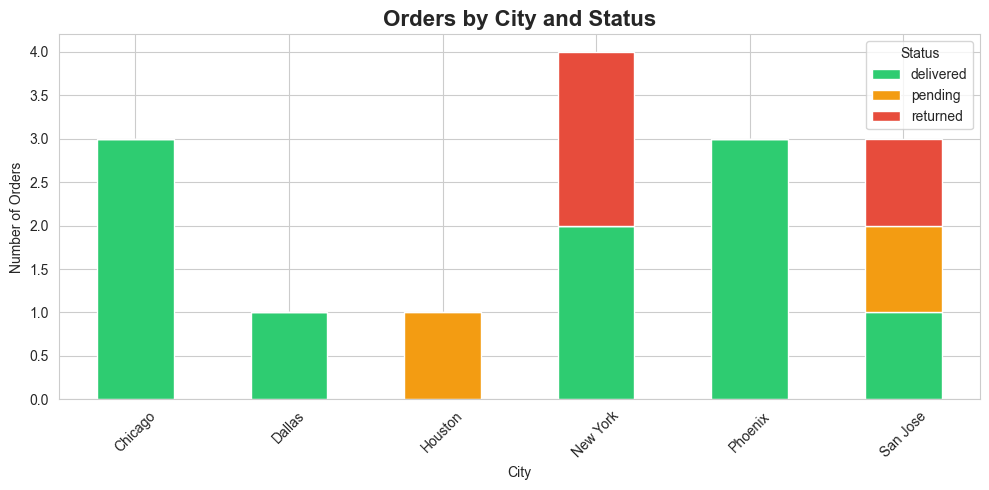

In [15]:

# crosstab counts combinations of two columns
# Like a pivot table in Excel!
city_status = pd.crosstab(df['city'], df['status'])

# print is helpful for non-interactive debugging vs display() is better for interactive exploration
print(city_status) # Debug: check the crosstab output before plotting
display(city_status) # Check the structure of city_status before plotting

city_status.plot(kind='bar',
                 stacked=True,
                 color=['#2ecc71', '#f39c12', '#e74c3c'], # Add a color for the 'delivered','pending' and 'returned' statuses
                 figsize=(10, 5))

plt.title('Orders by City and Status', fontsize=16, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)  # rotate x labels so they don't overlap
plt.legend(title='Status')
plt.tight_layout()
plt.show()

**Heat Map**

order_month_name
April       4
August      8
February    2
January     1
July        7
June        6
March       3
May         5
Name: order_month, dtype: int32

order_month_name
January     1
February    2
March       3
April       4
May         5
June        6
July        7
August      8
Name: order_month, dtype: int32

status,delivered,pending,returned
order_month_name,,,
January,2,0,0
February,1,0,1
March,1,1,0
April,1,0,1
May,2,0,0
June,1,1,0
July,2,0,0
August,0,0,1


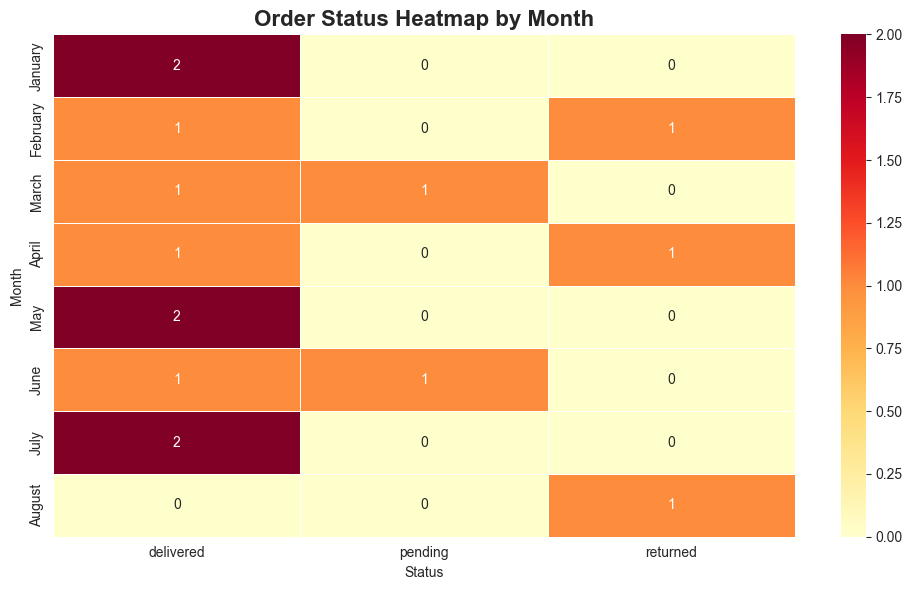

In [16]:
# A heatmap shows intensity using color
# Darker = higher value, lighter = lower value

# Create the pivot table (rows=month, columns=status, values=count)
heatmap_data = df.pivot_table(index='order_month_name',
                               columns='status',
                               values='order_id',
                               aggfunc='count',
                               fill_value=0)

# Sort by month number
month_order = df.groupby('order_month_name')['order_month'].first() 
display(month_order) # Debug: check the month order before reindexing
# Above we've monthly order sorted alphabetically by month name, but we want chronological order

month_order = df.groupby('order_month_name')['order_month'].first().sort_values() 
display(month_order) # Debug: check the month order before reindexing
# Now we have the correct chronological order of months

heatmap_data = heatmap_data.reindex(month_order.index)
display(heatmap_data)

fig, ax = plt.subplots(figsize=(10, 6)) # Set the figure size to make it more readable
sns.heatmap(heatmap_data,
            annot=True,        # show numbers inside cells
            fmt='d',           # format as integers
            cmap='YlOrRd',     # color scheme: yellow → orange → red
            linewidths=0.5,    # add lines between cells
            ax=ax              # axis to plot on       
            )

ax.set_title('Order Status Heatmap by Month', fontsize=16, fontweight='bold')
ax.set_xlabel('Status')
ax.set_ylabel('Month')

plt.tight_layout()
plt.show()

## 📊 Key Business Insights from Visualizations

### Order Status
- **Delivered** orders dominate overall, so we've a healthy fulfillment rate
- **3 returns** detected and it is worth investigating product quality or descriptions

### City Performance
- ✅ **Chicago, Dallas, Phoenix** — strong markets with high delivery rates
- ⚠️ **Houston** — all orders stuck in pending, possible fulfillment issue
- ⚠️ **New York** — high return rate, investigate product-market fit
- 🔍 **San Jose** — mixed performance, monitor closely

### Monthly Trend
- Consistent order volume Jan–July
- August dip detected — possible seasonal pattern, needs more data to confirm

### Recommendations
1. Prioritize investigating Houston's pending orders immediately
2. Survey New York customers to understand return reasons
3. Consider targeted promotions in August to counter seasonal dip

**Moving onto Modeling**

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print('✅ ML libraries imported!')

✅ ML libraries imported!


In [18]:
# STEP 1: Filter to only delivered and returned orders
# We exclude 'pending' because we don't know their outcome yet

model_df = df[df['status'].isin(['delivered', 'returned'])].copy()

print(f'Rows available for modeling: {len(model_df)}')
print(f'Status breakdown:\n{model_df["status"].value_counts()}')

Rows available for modeling: 13
Status breakdown:
status
delivered    10
returned      3
Name: count, dtype: int64


In [19]:
# STEP 2: Convert text columns into numbers
# Machine learning models only understand numbers — not text like "Chicago" or "Gmail"
# LabelEncoder converts each unique text value to a number automatically

# Example: Chicago=0, Dallas=1, Houston=2, New York=3 etc.

le_city       = LabelEncoder()
le_email      = LabelEncoder()
le_status     = LabelEncoder()

# 💡 fit_transform() does two things at once 
# fit = learn the unique values, transform = convert them to numbers.

model_df['city_encoded']       = le_city.fit_transform(model_df['city'])
model_df['email_encoded']      = le_email.fit_transform(model_df['email_type'])
model_df['status_encoded']     = le_status.fit_transform(model_df['status'])

print('──── Encoding Reference ────')
print('Cities:     ', dict(zip(le_city.classes_, le_city.transform(le_city.classes_))))
print('Email type: ', dict(zip(le_email.classes_, le_email.transform(le_email.classes_))))
print('Status:     ', dict(zip(le_status.classes_, le_status.transform(le_status.classes_))))

──── Encoding Reference ────
Cities:      {'Chicago': np.int64(0), 'Dallas': np.int64(1), 'New York': np.int64(2), 'Phoenix': np.int64(3), 'San Jose': np.int64(4)}
Email type:  {'Gmail': np.int64(0), 'Other': np.int64(1)}
Status:      {'delivered': np.int64(0), 'returned': np.int64(1)}


In [20]:
# Define features (X) and target (y)
# Features = the inputs the model learns FROM
# Target   = the output the model learns TO predict

# Think of it like:
# X = ingredients, y = the dish

X = model_df[['city_encoded', 'email_encoded', 'days_as_customer']]
y = model_df['status_encoded']

print('──── Features (X) ────')
display(X.head())
print(f'\n──── Target (y) ────')
print(y.value_counts())

──── Features (X) ────


,city_encoded,email_encoded,days_as_customer
0,2,0,666
1,0,1,542
2,4,0,393
3,2,0,701
5,3,0,274



──── Target (y) ────
status_encoded
0    10
1     3
Name: count, dtype: int64


In [21]:
# Split data into training and testing sets
# test_size=0.2 means 80% trains the model, 20% tests it
# random_state=42 means the split is reproducible (same split every time)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Training rows: {len(X_train)}')
print(f'Testing rows:  {len(X_test)}')

Training rows: 10
Testing rows:  3


In [24]:
# Train the Random Forest model
# Random Forest builds many decision trees and combines their predictions
# Think of it like asking 100 people for their opinion and taking a majority vote

model = RandomForestClassifier(
    n_estimators=100,  # build 100 decision trees
    random_state=42
)

# .fit() is where the actual learning happens
# We feed it the training data and it finds patterns
model.fit(X_train, y_train)

print('✅ Model trained successfully!')
print(f'   Trained on {len(X_train)} orders')
print(f'   Using {X.shape[1]} features: city, email type, days as customer')

✅ Model trained successfully!
   Trained on 10 orders
   Using 3 features: city, email type, days as customer


──── Classification Report ────
              precision    recall  f1-score   support

   delivered       1.00      0.67      0.80         3
    returned       0.00      0.00      0.00         0

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3

──── Confusion Matrix ────


c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

array([[2, 1],
       [0, 0]])

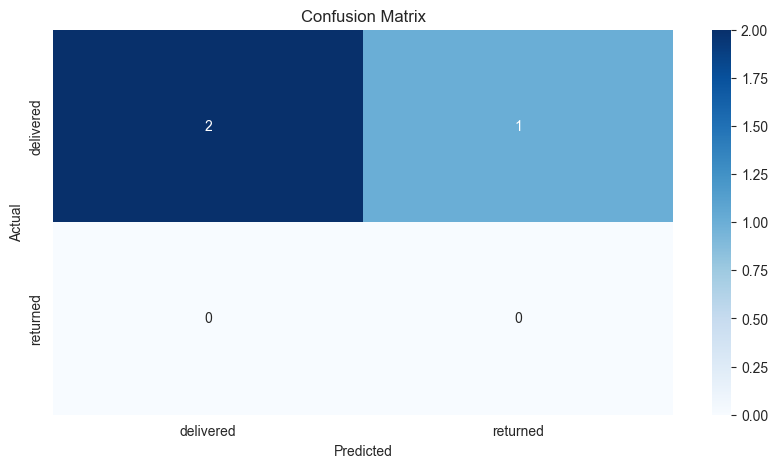

In [25]:
# Evaluate
y_pred = model.predict(X_test)

print('──── Classification Report ────')
print(classification_report(y_test, y_pred,
      target_names=le_status.classes_))

print('──── Confusion Matrix ────')
cm = confusion_matrix(y_test, y_pred)
display(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_status.classes_,
            yticklabels=le_status.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

C:\Users\Hanisha\AppData\Local\Temp\ipykernel_13936\3872546630.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette='viridis')


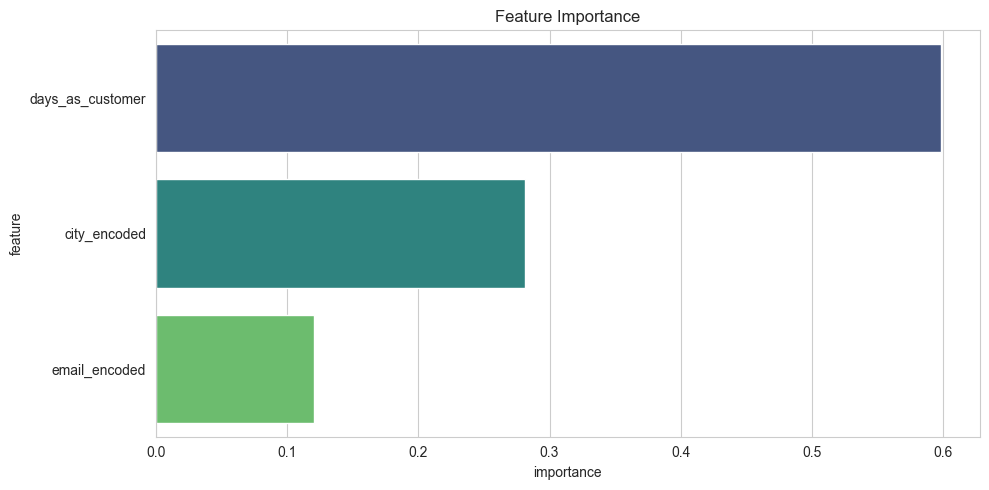

In [26]:
# Feature importance — which features drove predictions most?
importances = pd.DataFrame({
    'feature':   X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=importances, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

**Permutation Importance**

In [28]:

# Permutation importance works on ANY sklearn model 
# ~ It shuffles each feature and sees how much the model's performance drops
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=10)
display(result)

{'importances_mean': array([ 0. , -0.2, -0.2]),
 'importances_std': array([0.        , 0.16329932, 0.16329932]),
 'importances': array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
        [-0.33333333, -0.33333333,  0.        ,  0.        , -0.33333333,
          0.        ,  0.        , -0.33333333, -0.33333333, -0.33333333],
        [-0.33333333,  0.        , -0.33333333,  0.        , -0.33333333,
         -0.33333333, -0.33333333,  0.        , -0.33333333,  0.        ]])}

,feature,importance_mean,importance_std
0,city_encoded,0.0,0.000000
2,days_as_customer,-0.2,0.163299
1,email_encoded,-0.2,0.163299


C:\Users\Hanisha\AppData\Local\Temp\ipykernel_13936\691188247.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


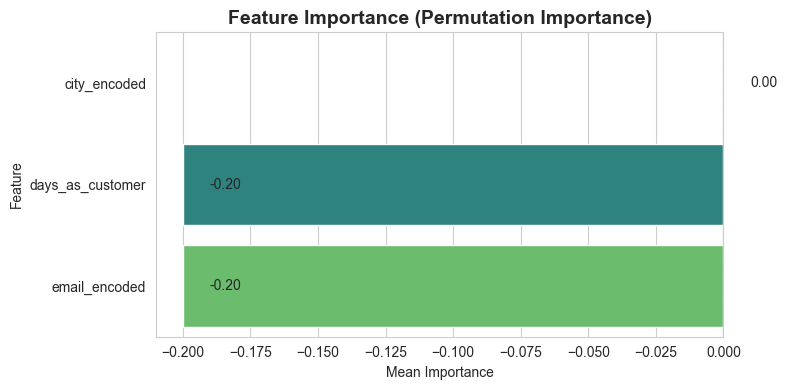

In [32]:
# Use perm_df from permutation_importance result to visualize feature importance
importance_df = perm_df.sort_values('importance_mean', ascending=False)
display(importance_df)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=importance_df,
    x='importance_mean',
    y='feature',
    # xerr=importance_df['importance_std'], # Add error bars to show variability
    ax=ax,
    palette='viridis'
)

ax.set_title('Feature Importance (Permutation Importance)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Importance')
ax.set_ylabel('Feature')
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)

for idx, row in importance_df.iterrows():
    ax.text(row['importance_mean'] + 0.01, idx, f"{row['importance_mean']:.2f}", va='center')

plt.tight_layout()
plt.show()

**SHAP**

In [ ]:
import shap 

# SHAP (SHapley Additive exPlanations) assigns each feature an importance value
# for a particular prediction, based on game theory concepts.
# It explains WHY the model made a certain prediction for each individual order.

# Create SHAP explainer for our Random Forest
explainer = shap.TreeExplainer(model)
# SHAP for non-Random Forest models would use shap.Explainer() instead

# SHAP values are calculated for each class in a multi-class model
# For example, if we have 3 classes, shap_values will be a list of 3 arrays:
# shap_values[0] = SHAP values for class 0 (e.g., 'delivered') 
# shap_values[1] = SHAP values for class 1 (e.g., 'returned')


# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape: {len(shap_values)} classes')
print(f'For each class, shape: {shap_values[0].shape}')
print(f'Classes: {le_status.classes_}')

SHAP values shape: 3 classes
For each class, shape: (3, 2)
Classes: ['delivered' 'returned']


In [ ]:
shap_values 
# It's a single 3D array (3 observations, 3 features, 2 classes)
# shap_values[:, :, 1] slices out class index 1 (returned) across all observations and features,
# giving us the 2D matrix SHAP expects.

array([[[ 0.04530367, -0.04530367],
        [-0.07823571,  0.07823571],
        [-0.25206796,  0.25206796]],

       [[ 0.00463727, -0.00463727],
        [ 0.07776019, -0.07776019],
        [ 0.16260255, -0.16260255]],

       [[-0.08627953,  0.08627953],
        [-0.06085185,  0.06085185],
        [ 0.29213138, -0.29213138]]])

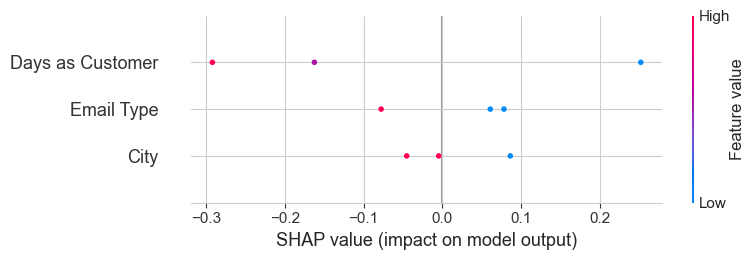

In [ ]:
# Plot 1: Summary plot — feature importance + impact direction
# Each dot = one prediction
# Red = high feature value, Blue = low feature value
# X axis = SHAP value (impact on prediction)

shap.summary_plot(
    shap_values[:, :, 1],  # index 1 = 'returned' class
    X_test,
    feature_names=['City', 'Email Type', 'Days as Customer'],
    plot_type='dot',
    show=True
)

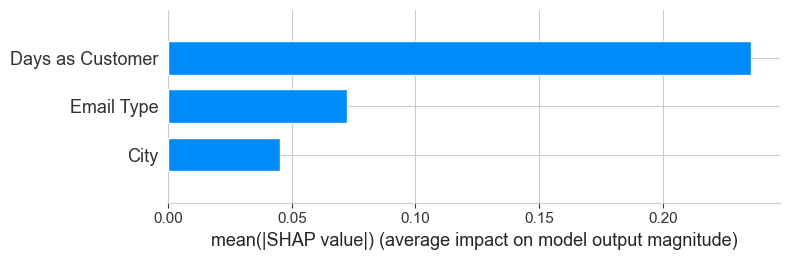

In [39]:
# Plot 2: Bar plot — mean absolute SHAP values (cleaner importance view)
shap.summary_plot(
    shap_values[:,:,1],  # index 1 = 'returned' class
    X_test,
    feature_names=['City', 'Email Type', 'Days as Customer'],
    plot_type='bar',
    show=True
)

In [41]:
print(f'expected_value: {explainer.expected_value}')
print(f'expected_value type: {type(explainer.expected_value)}')
print(f'shap_values[0, :, 1]: {shap_values[0, :, 1]}')

expected_value: [0.705 0.295]
expected_value type: <class 'numpy.ndarray'>
shap_values[0, :, 1]: [-0.04530367  0.07823571  0.25206796]


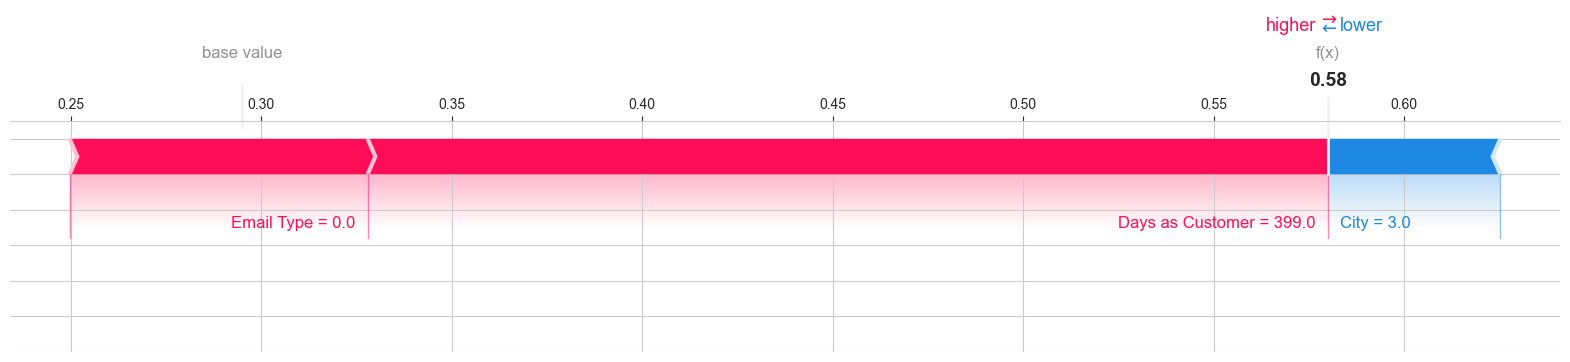

<Figure size 1000x500 with 0 Axes>

In [42]:
# Use matplotlib=True to avoid JavaScript rendering issues in VS Code
shap.force_plot(
    base_value=float(explainer.expected_value[1]),   # cast to float explicitly
    shap_values=shap_values[0, :, 1],                # first observation, returned class
    features=X_test.iloc[0],
    feature_names=['City', 'Email Type', 'Days as Customer'],
    matplotlib=True
)
plt.tight_layout()
plt.show()

## ⚠️ Note on Feature Importance Discrepancy

Random Forest's built-in `feature_importances_` (MDI) and SHAP values
disagree on the relative importance of Email Type vs City.

**MDI ranking:** Days as Customer → City → Email Type
**SHAP ranking:** Days as Customer → Email Type → City

SHAP is preferred as it is theoretically grounded in Shapley values,
computed on test data, and accounts for feature interactions.
MDI is known to be biased toward features used in early tree splits.

In [ ]:
import lime
import lime.lime_tabular

# Create LIME explainer
# training_data: LIME needs to understand the feature distributions
# mode: 'classification' since we're predicting classes
# feature_names: column labels for the plot
# class_names: our target labels

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    mode='classification',
    feature_names=['City', 'Email Type', 'Days as Customer'],
    class_names=le_status.classes_,
    random_state=42
)

print('✅ LIME explainer created!')

✅ LIME explainer created!


In [ ]:
# Explain the first test observation
# LIME perturbs the input, runs many predictions, 
# then fits a simple linear model around that neighborhood

print(model.predict_proba(X_test))   #probability predictions for the test set, to verify predict_fn works correctly
lime_exp = lime_explainer.explain_instance(
    data_row=X_test.values[0],          # the observation to explain
    predict_fn=model.predict_proba,      # model's probability predictions
    num_features=3                        # show all 3 features
)

print(lime_exp.as_list())  # Get the explanation as a list of (feature, contribution) pairs
# Print the prediction probabilities first
probs = model.predict_proba(X_test.iloc[[0]])
print('──── Prediction Probabilities ────')
for cls, prob in zip(le_status.classes_, probs[0]):
    print(f'  {cls}: {prob:.2%}')

print(f'\n──── Actual Status ────')
print(f'  {le_status.inverse_transform(y_test.values)[0]}')

[[0.42 0.58]
 [0.95 0.05]
 [0.85 0.15]]
[('Days as Customer <= 417.25', 0.25560648569968397), ('Email Type <= 0.00', 0.20500584103040603), ('City > 2.75', -0.013782729593976362)]
──── Prediction Probabilities ────
  delivered: 42.00%
  returned: 58.00%

──── Actual Status ────
  delivered


c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


[('Days as Customer <= 417.25', 0.25560648569968397), ('Email Type <= 0.00', 0.20500584103040603), ('City > 2.75', -0.013782729593976362)]


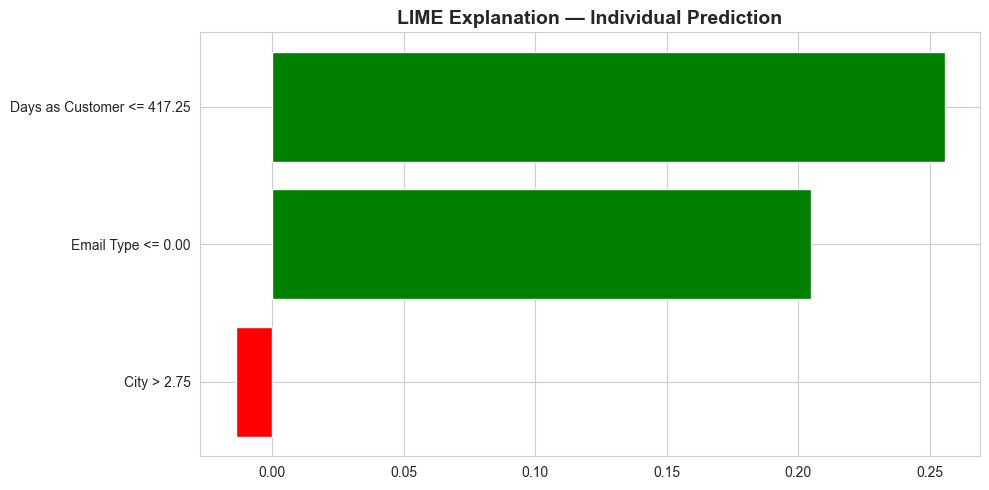

In [ ]:
# Visualize LIME explanation
# Green bars = features pushing toward predicted class
# Red bars   = features pushing against predicted class

print(lime_exp)
lime_exp.as_pyplot_figure()
plt.title('LIME Explanation — Individual Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

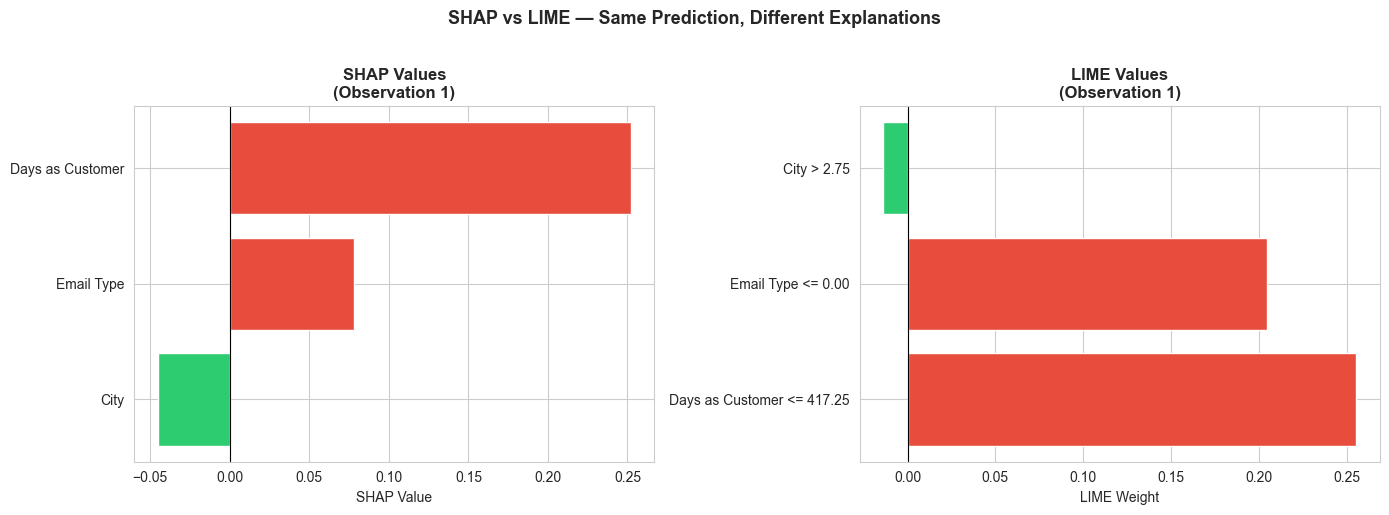

In [52]:
# Compare SHAP vs LIME side by side for the same observation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: SHAP values for observation 0 ──────────────────────
feature_names = ['City', 'Email Type', 'Days as Customer']
shap_vals     = shap_values[0, :, 1]  # first obs, returned class

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in shap_vals]
axes[0].barh(feature_names, shap_vals, color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('SHAP Values\n(Observation 1)', fontweight='bold')
axes[0].set_xlabel('SHAP Value')

# ── Right: LIME values for observation 0 ─────────────────────
lime_vals  = lime_exp.as_list()
lime_names = [x[0] for x in lime_vals]
lime_scores = [x[1] for x in lime_vals]

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in lime_scores]
axes[1].barh(lime_names, lime_scores, color=colors)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('LIME Values\n(Observation 1)', fontweight='bold')
axes[1].set_xlabel('LIME Weight')

plt.suptitle('SHAP vs LIME — Same Prediction, Different Explanations',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**XGBOOST - WITH CROSS VALIDATION and PARAMETER TUNING****

In [55]:
from sklearn.model_selection import (cross_val_score, 
                                      StratifiedKFold,
                                      GridSearchCV,
                                      RandomizedSearchCV,
                                      learning_curve)

print('✅ CV and tuning libraries imported!')

✅ CV and tuning libraries imported!


In [59]:
from sklearn.metrics import accuracy_score, roc_auc_score

In [62]:
from xgboost import XGBClassifier

# XGBoost expects numeric labels starting from 0 — which we already have
# from our LabelEncoder (delivered=0, returned=1)

xgb_model = XGBClassifier(
    n_estimators=100,      # number of boosting rounds
    max_depth=3,           # max tree depth — keeps it from overfitting on small data
    learning_rate=0.1,     # shrinkage — how much each tree contributes
    random_state=42,
    eval_metric='logloss', # suppresses a default warning
    verbosity=0            # suppresses training output
)

xgb_model.fit(X_train, y_train)
print('✅ XGBoost model trained!')

✅ XGBoost model trained!


In [ ]:
'''
# StratifiedKFold preserves class distribution in each fold
# Critical for imbalanced datasets — always prefer over plain KFold

# plain KFold function would be:
# cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv = StratifiedKFold(
    n_splits=5,      # 5 folds — standard choice
    shuffle=True,
    random_state=42
)

# Evaluate both models with CV — using multiple metrics
metrics = ['accuracy', 'roc_auc', 'f1']

print('──── Cross-Validation Results ────\n')
for metric in metrics:
    rf_scores  = cross_val_score(model,     X, y, cv=cv, scoring=metric)
    xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring=metric)
    
    print(f'{metric.upper()}')
    print(f'  Random Forest:  {rf_scores.mean():.3f} ± {rf_scores.std():.3f}')
    print(f'  XGBoost:        {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}')
    print()
    '''
    

──── Cross-Validation Results ────



c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


ACCURACY
  Random Forest:  0.800 ± 0.163
  XGBoost:        0.800 ± 0.163



c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics

ROC_AUC
  Random Forest:  nan ± nan
  XGBoost:        nan ± nan



c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


F1
  Random Forest:  0.000 ± 0.000
  XGBoost:        0.000 ± 0.000



c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [71]:
# StratifiedKFold preserves class distribution in each fold
# Critical for imbalanced datasets — always prefer over plain KFold

# plain KFold function would be:
# cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# ── Evaluate with multiple metrics ───────────────────────────
# Why multiple metrics?
# Accuracy alone is misleading with imbalanced classes
# e.g. predicting 'delivered' every time = 77% accuracy but useless model

metrics = {
    'Accuracy': 'accuracy',    # overall correct predictions
    'ROC-AUC':  'roc_auc',    # discrimination ability across thresholds
    'F1':       'f1',          # harmonic mean of precision and recall
    'Precision':'precision',   # of predicted returned, how many were right
    'Recall':   'recall'       # of actual returned, how many did we catch
}

print('──── Cross-Validation Results (5-Fold Stratified) ────\n')

cv_results = []

#note right now using models built only on train_Data

for metric_name, metric_scorer in metrics.items():
    rf_scores  = cross_val_score(model,       X, y, cv=cv, scoring=metric_scorer)
    xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring=metric_scorer)
    
    cv_results.append({
        'Metric':           metric_name,
        'RF Mean':          rf_scores.mean().round(3),
        'RF Std':           rf_scores.std().round(3),
        'XGB Mean':         xgb_scores.mean().round(3),
        'XGB Std':          xgb_scores.std().round(3),
    })
    
    print(f'{metric_name}:')
    print(f'  Random Forest:  {rf_scores.mean():.3f} ± {rf_scores.std():.3f}  | per fold: {rf_scores.round(3)}')
    print(f'  XGBoost:        {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}  | per fold: {xgb_scores.round(3)}')
    print()

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

──── Cross-Validation Results (5-Fold Stratified) ────

Accuracy:
  Random Forest:  0.767 ± 0.024  | per fold: [0.8  0.75 0.75]
  XGBoost:        0.767 ± 0.024  | per fold: [0.8  0.75 0.75]

ROC-AUC:
  Random Forest:  0.639 ± 0.219  | per fold: [0.75  0.333 0.833]
  XGBoost:        0.500 ± 0.000  | per fold: [0.5 0.5 0.5]

F1:
  Random Forest:  0.000 ± 0.000  | per fold: [0. 0. 0.]
  XGBoost:        0.000 ± 0.000  | per fold: [0. 0. 0.]



c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

Precision:
  Random Forest:  0.000 ± 0.000  | per fold: [0. 0. 0.]
  XGBoost:        0.000 ± 0.000  | per fold: [0. 0. 0.]

Recall:
  Random Forest:  0.000 ± 0.000  | per fold: [0. 0. 0.]
  XGBoost:        0.000 ± 0.000  | per fold: [0. 0. 0.]



,Metric,RF Mean,RF Std,XGB Mean,XGB Std
0,Accuracy,0.767,0.024,0.767,0.024
1,ROC-AUC,0.639,0.219,0.500,0.000
2,F1,0.000,0.000,0.000,0.000
3,Precision,0.000,0.000,0.000,0.000
4,Recall,0.000,0.000,0.000,0.000


**GridSearchCV**

In [72]:
# Define the parameter grid
# GridSearchCV tries EVERY combination — 4x3x3x2 = 72 fits here

param_grid = {
    'n_estimators':  [50, 100, 200, 300],
    'max_depth':     [2, 3, 4],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

scoring = {
    'AUC':       'roc_auc',
    'F1':        'f1',
    'Precision': 'precision',
    'Recall':    'recall',
    'Accuracy':  'accuracy'
}

grid_search_multi = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid=param_grid,
    cv=cv,                    # use our stratified CV
    scoring=scoring, 
    refit  = 'AUC',        # which metric to optimize for the final model
    # Don't need refit, if we know the one metric to optimize, just input in scoring
    # GridSearch fits only for one metric at a time -
    # so, choose the most important one for tuning
    n_jobs=-1,                # use all CPU cores
    verbose=1                 # print progress
)

grid_search_multi.fit(X, y)

print('\n──── GridSearchCV Results ────')
print(f'Best ROC-AUC: {grid_search_multi.best_score_:.3f}')
print(f'Best params:  {grid_search_multi.best_params_}')

Fitting 3 folds for each of 72 candidates, totalling 216 fits

──── GridSearchCV Results ────
Best ROC-AUC: 0.500
Best params:  {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}


In [ ]:
'''
Checking for NaN values in CV results is crucial because it can indicate
issues with certain parameter combinations or data splits. 
NaN values in metrics like AUC often arise when the model fails to make
valid predictions for a fold, which can happen due to class imbalance, 
small sample sizes, or incompatible parameter settings. 
By identifying which combinations lead to NaN scores,
we can investigate further to understand the root cause and 
potentially adjust our approach (e.g., using different parameters, 
adding more data, or applying techniques to handle imbalance).
'''
'''
# Check which combinations are producing NaN
nan_mask = cv_results['mean_test_AUC'].isna()
print(f'Total combinations: {len(cv_results)}')
print(f'NaN AUC combinations: {nan_mask.sum()}')

# Look at the split scores for NaN rows — which fold is failing?
nan_cols = [c for c in cv_results.columns if 'split' in c and 'AUC' in c]
print('\n──── Per-fold AUC scores for NaN combinations ────')
display(cv_results[nan_cols].head(10).round(3))

# Also check class distribution per fold
print('\n──── Class distribution ────')
print(pd.Series(le_status.inverse_transform(y)).value_counts())
print(f'\nTotal samples: {len(y)}')
print(f'With 5 folds, test fold size: ~{len(y)//5} rows')
'''

Total combinations: 72
NaN AUC combinations: 72

──── Per-fold AUC scores for NaN combinations ────


,split0_test_AUC,split1_test_AUC,split2_test_AUC,split3_test_AUC,split4_test_AUC
0,0.5,0.5,0.5,NaN,NaN
1,0.5,0.5,0.5,NaN,NaN
2,0.5,0.5,0.5,NaN,NaN
3,0.5,0.5,0.5,NaN,NaN
4,0.5,0.5,0.5,NaN,NaN
5,0.5,0.5,0.5,NaN,NaN
6,0.5,0.5,0.5,NaN,NaN
7,0.5,0.5,0.5,NaN,NaN
8,0.5,0.5,0.5,NaN,NaN
9,0.5,0.5,0.5,NaN,NaN



──── Class distribution ────
delivered    10
returned      3
Name: count, dtype: int64

Total samples: 13
With 5 folds, test fold size: ~2 rows


## ⚠️ Note on Cross-Validation Strategy

**Problem:** 5-fold StratifiedKFold produced NaN ROC-AUC scores.

**Root cause:** With only 13 samples and 2 classes (10 delivered, 3 returned),
5-fold CV creates test folds of ~2 rows. With only 3 'returned' samples total,
some folds inevitably contained only one class — making ROC-AUC undefined
(requires both classes to be present in test fold).

**Fix:** Reduced to 3-fold CV → test folds of ~4 rows → both classes
guaranteed in every fold via stratification.

**General rule:** 
n_splits should satisfy: n_splits <= n_samples_minority_class
In our case: minority class = 3 → max reliable folds = 3

**If we want to use other metrics, we can convert CV to DF and get summaries of all metrics, and use the appropriate one**

In [73]:
# Convert CV results to DataFrame — contains scores for ALL metrics
cv_results = pd.DataFrame(grid_search_multi.cv_results_)

# Extract only the mean test scores for each metric
score_cols = [f'mean_test_{m}' for m in scoring.keys()]
param_cols = [c for c in cv_results.columns if c.startswith('param_')]

results_summary = cv_results[param_cols + score_cols].copy()

# Rename for readability
results_summary.columns = (
    [c.replace('param_', '') for c in param_cols] +
    [c.replace('mean_test_', '') for c in score_cols]
)

# Sort by AUC
results_summary = results_summary.sort_values('AUC', ascending=False)

print('──── Top 10 Parameter Combinations ────')
display(results_summary.head(10).round(3))

──── Top 10 Parameter Combinations ────


,learning_rate,max_depth,n_estimators,subsample,AUC,F1,Precision,Recall,Accuracy
0,0.01,2,50,0.8,0.5,0.0,0.0,0.0,0.767
1,0.01,2,50,1.0,0.5,0.0,0.0,0.0,0.767
2,0.01,2,100,0.8,0.5,0.0,0.0,0.0,0.767
3,0.01,2,100,1.0,0.5,0.0,0.0,0.0,0.767
4,0.01,2,200,0.8,0.5,0.0,0.0,0.0,0.767
5,0.01,2,200,1.0,0.5,0.0,0.0,0.0,0.767
6,0.01,2,300,0.8,0.5,0.0,0.0,0.0,0.767
7,0.01,2,300,1.0,0.5,0.0,0.0,0.0,0.767
8,0.01,3,50,0.8,0.5,0.0,0.0,0.0,0.767
9,0.01,3,50,1.0,0.5,0.0,0.0,0.0,0.767


**RandomizedCV**

In [74]:
from scipy.stats import uniform, randint

# RandomizedSearchCV samples randomly from distributions
# Much faster than GridSearch when parameter space is large

param_distributions = {
    'n_estimators':  randint(50, 500),          # random int between 50-500
    'max_depth':     randint(2, 8),              # random int between 2-8
    'learning_rate': uniform(0.01, 0.3),         # random float between 0.01-0.31
    'subsample':     uniform(0.6, 0.4),          # random float between 0.6-1.0
    'colsample_bytree': uniform(0.6, 0.4),       # feature subsampling per tree
    'min_child_weight': randint(1, 6)            # minimum samples per leaf
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_distributions=param_distributions,
    n_iter=50,               # try 50 random combinations
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X, y)

print('\n──── RandomizedSearchCV Results ────')
print(f'Best ROC-AUC: {random_search.best_score_:.3f}')
print(f'Best params:  {random_search.best_params_}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits

──── RandomizedSearchCV Results ────
Best ROC-AUC: 0.500
Best params:  {'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.2952142919229748), 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 70, 'subsample': np.float64(0.6624074561769746)}


**ModelCOmparison - Straitified fold, GridSearchCV, RandomizedSearchCV**

In [75]:
# Train final tuned model using best params from GridSearch
xgb_tuned = XGBClassifier(
    **grid_search_multi.best_params_,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_tuned_random = XGBClassifier(
    **random_search.best_params_,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# CV scores for all three
models = {
    'Random Forest':    model,
    'XGBoost Default':  xgb_model,
    'XGBoost Grid Tuned':    xgb_tuned,
    'XGBoost Random Tuned':  xgb_tuned_random
}

results = []
for name, m in models.items():
    for metric in ['accuracy', 'roc_auc', 'f1']:
        scores = cross_val_score(m, X, y, cv=cv, scoring=metric)
        results.append({
            'Model':  name,
            'Metric': metric.upper(),
            'Mean':   scores.mean().round(3),
            'Std':    scores.std().round(3)
        })

results_df = pd.DataFrame(results)

# Pivot for clean display
pivot = results_df.pivot_table(
    index='Model',
    columns='Metric',
    values='Mean'
).round(3)

print('──── Model Comparison (CV Mean Scores) ────')
display(pivot)

──── Model Comparison (CV Mean Scores) ────


Metric,ACCURACY,F1,ROC_AUC
Model,,,
Random Forest,0.767,0.0,0.639
XGBoost Default,0.767,0.0,0.500
XGBoost Grid Tuned,0.767,0.0,0.500
XGBoost Random Tuned,0.767,0.0,0.500


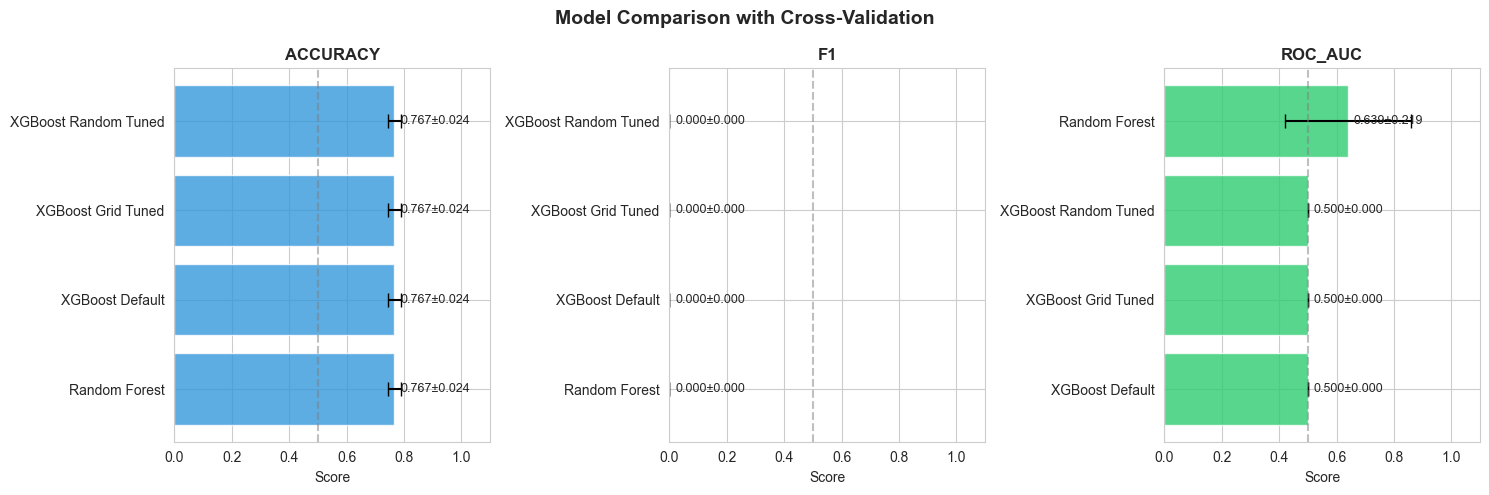

In [76]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['ACCURACY', 'F1', 'ROC_AUC']
colors  = ['#3498db', '#e74c3c', '#2ecc71']

for ax, metric, color in zip(axes, ['ACCURACY', 'F1', 'ROC_AUC'], colors):
    # filter and sort
    data = results_df[results_df['Metric'] == metric].sort_values('Mean')
    
    bars = ax.barh(data['Model'], data['Mean'],
                   xerr=data['Std'],           # error bars show std
                   color=color, alpha=0.8,
                   capsize=5)
    
    ax.set_xlim(0, 1.1)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Score')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)  # baseline
    
    # Add value labels
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(row['Mean'] + 0.02, bar.get_y() + bar.get_height()/2,
                f"{row['Mean']:.3f}±{row['Std']:.3f}",
                va='center', fontsize=9)

plt.suptitle('Model Comparison with Cross-Validation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:2130: RuntimeWarning: Removed duplicate entries from 'train_sizes'. Number of ticks will be less than the size of 'train_sizes': 7 instead of 8.
  warnings.warn(
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:2130: RuntimeWarning: Removed duplicate entries from 'train_sizes'. Number of ticks will be less than the size of 'train_sizes': 7 instead of 8.
  warnings.warn(
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:2130: RuntimeWarning: Removed duplicate entries from 'train_sizes'. Number of ticks will be less than the size of 'train_sizes': 7 instead of 8.
  warnings.warn(
c:\Users\Hanisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:2130: RuntimeWarning: Removed duplicate entries from 'trai

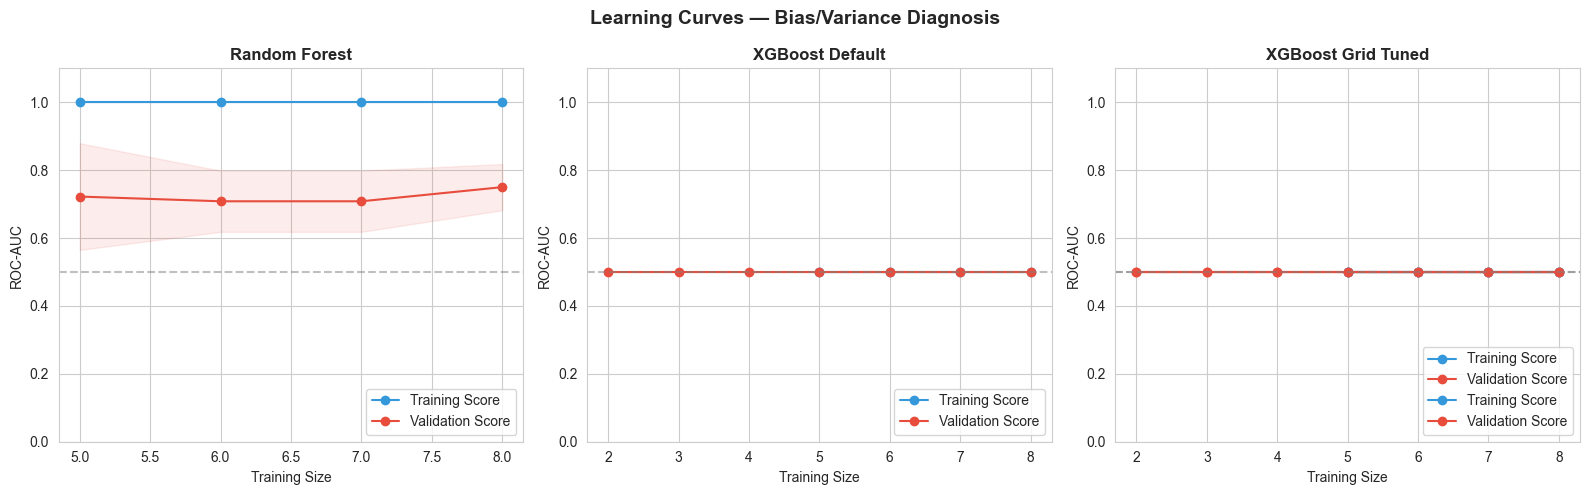

In [78]:
# Learning curves diagnose bias/variance tradeoff
# Shows how model performance changes as training data grows

def plot_learning_curve(estimator, X, y, title, cv, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=cv,
        n_jobs=-1,
        train_sizes=np.linspace(0.3, 1.0, 8),  # 30% to 100% of training data
        scoring='roc_auc'
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    
    # Plot training score
    ax.plot(train_sizes, train_mean, 'o-', color='#3498db', label='Training Score')
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.1, color='#3498db')
    
    # Plot validation score
    ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation Score')
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.1, color='#e74c3c')
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Training Size')
    ax.set_ylabel('ROC-AUC')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)  # baseline

# Plot for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_learning_curve(model,     X, y, 'Random Forest',   cv, axes[0])
plot_learning_curve(xgb_model, X, y, 'XGBoost Default', cv, axes[1])
plot_learning_curve(xgb_tuned, X, y, 'XGBoost Random Tuned',   cv, axes[2])
plot_learning_curve(xgb_tuned_random, X, y, 'XGBoost Grid Tuned',   cv, axes[2])

plt.suptitle('Learning Curves — Bias/Variance Diagnosis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [80]:
# Check what's actually happening in each fold
train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=xgb_model,
    X=X, y=y,
    cv=cv,
    n_jobs=-1,
    train_sizes=np.linspace(0.3, 1.0, 6),
    scoring='roc_auc',
    error_score=np.nan    # ← return NaN instead of raising error
)

print('──── Training sizes (absolute) ────')
print(train_sizes_abs)

print('\n──── Validation scores per fold ────')
print(val_scores)

print('\n──── Any NaN in val scores? ────')
print(np.isnan(val_scores).any())

──── Training sizes (absolute) ────
[2 3 4 5 6 8]

──── Validation scores per fold ────
[[0.5 0.5 0.5]
 [0.5 0.5 0.5]
 [0.5 0.5 0.5]
 [0.5 0.5 0.5]
 [0.5 0.5 0.5]
 [0.5 0.5 0.5]]

──── Any NaN in val scores? ────
False


## ⚠️ Note on XGBoost Learning Curves

XGBoost validation scores are flat at 0.5 (random baseline) across all
training sizes. This is expected — not a bug.

**Root cause:** With only 13 samples total and 3 'returned' examples,
XGBoost receives as few as 2-8 training rows per learning curve step.
This is insufficient to learn a meaningful decision boundary, so the
model defaults to random guessing on the validation set.

**Random Forest** shows higher validation scores because it is less
sensitive to extremely small training sets due to bootstrap aggregation.

**Key takeaway:** Learning curves are most meaningful with 500+ samples.
On this dataset they serve as a demonstration of the technique rather
than a reliable diagnostic tool. In production, this would signal an
immediate need for more training data.